<a href="https://colab.research.google.com/github/pometto/Colab/blob/main/Titanic_Yolcu_Kurtarma_Tahmini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Gerekli kütüphaneler ve veri Açıklama: kütüphaneleri yükle, veriyi Kaggle’dan çekmek istemezsen Colab’ın hazır örnek URL’sini kullanacağız.

In [ ]:
# 1. Kütüphaneler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow import keras

sns.set(style="whitegrid")


In [ ]:
# 2. Veri yükle - Colab ortamında doğrudan URL kullanıyoruz
train_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(train_url)
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Hızlı EDA (Keşifsel Veri Analizi) Açıklama: temel özet, eksik değerler, hedef dağılımı.

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
d

<Axes: xlabel='Survived', ylabel='count'>

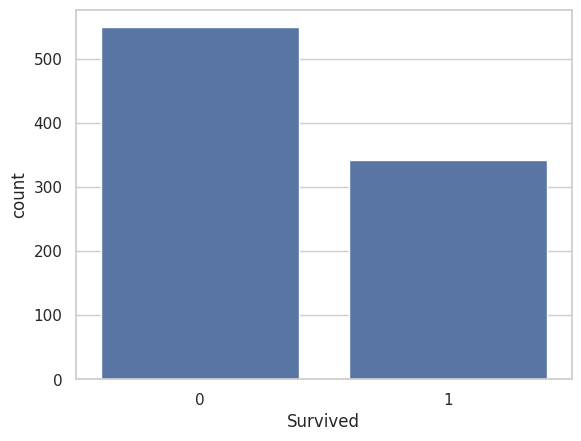

In [ ]:
# 3. Temel özet
print(df.shape)
print(df.info())
print(df.isnull().sum())

# Hedef değişken dağılımı
print(df['Survived'].value_counts(normalize=True))
sns.countplot(x='Survived', data=df)


Özellik mühendisliği & sütun seçimi Açıklama: kullanacağımız sütunları seç, basit feature engineering (Title çıkarma, Age dolgulama, Cabin deneme, Embarked doldurma). Kısa ve etkili.

In [ ]:
# 4. Yeni özellikler
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.')
df['Title'] = df['Title'].replace(['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'],'Rare')
df['Title'] = df['Title'].replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})

# Kabin bilgisi: varsa 1 yoksa 0
df['HasCabin'] = df['Cabin'].notnull().astype(int)

# Aile büyüklüğü
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Basit drop: PassengerId, Ticket, Name, Cabin (detail yerine HasCabin kullanıyoruz)
cols_to_drop = ['PassengerId','Ticket','Name','Cabin']
df = df.drop(columns=cols_to_drop)


Eğitim/Test bölmesi ve pipeline hazırlığı Açıklama: kategorik ve sayısal sütunları ayır, pipeline ile imputasyon + encoding + scaling uygula.

In [ ]:
# 5. Hedef ve özellikler
y = df['Survived']
X = df.drop(columns=['Survived'])

# Kategorik ve sayısal değişkenler
num_cols = ['Age','Fare','FamilySize','SibSp','Parch']
cat_cols = ['Pclass','Sex','Embarked','Title','HasCabin']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Pipeline bileşenleri
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])


Baseline modeller: Lojistik Regresyon ve Random Forest Açıklama: pipeline içine preprocessor + model koyup eğitim, sonrasında değerlendirme.

In [ ]:
# 6a. Lojistik regresyon pipeline
pipe_lr = Pipeline([
    ('preproc', preprocessor),
    ('clf', LogisticRegression(max_iter=1000))
])

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
print("Logistic Regression - Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# 6b. Random Forest
pipe_rf = Pipeline([
    ('preproc', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)
print("Random Forest - Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Logistic Regression - Accuracy: 0.8268156424581006
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.80      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.83       179

Random Forest - Accuracy: 0.7988826815642458
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       110
           1       0.75      0.72      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



Basit hyperparameter tuning (opsiyonel) Açıklama: RandomForest için GridSearch örneği.

In [ ]:
# 7. Basit GridSearch (küçük bir grid)
param_grid = {
    'clf__n_estimators': [50, 100],
    'clf__max_depth': [None, 5, 10]
}

grid = GridSearchCV(pipe_rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Grid best CV score:", grid.best_score_)


Best params: {'clf__max_depth': 5, 'clf__n_estimators': 100}
Grid best CV score: 0.8244656751699004


Basit Keras derin öğrenme modeli (opsiyonel — sklearn sonrası karşılaştırma) Açıklama: preprocessor ile veriyi dönüştürüp tekil bir dense network uygula.

In [ ]:
# 8. Keras için veriyi hazırla
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# Basit NN
model = keras.Sequential([
    keras.layers.InputLayer(input_shape=(X_train_proc.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train_proc, y_train, validation_split=0.2, epochs=30, batch_size=32, verbose=1)

# Değerlendirme
loss, acc = model.evaluate(X_test_proc, y_test, verbose=0)
print("NN test accuracy:", acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.6037 - loss: 0.6611 - val_accuracy: 0.6853 - val_loss: 0.5906
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.7238 - loss: 0.5707 - val_accuracy: 0.7622 - val_loss: 0.5357
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7851 - loss: 0.5036 - val_accuracy: 0.7692 - val_loss: 0.4939
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8067 - loss: 0.4566 - val_accuracy: 0.7832 - val_loss: 0.4688
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8031 - loss: 0.4463 - val_accuracy: 0.7972 - val_loss: 0.4570
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8208 - loss: 0.4227 - val_accuracy: 0.8322 - val_loss: 0.4552
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8264 - loss: 0.3866 - val_accuracy: 0.8322 - val_loss: 0.4537
Epoch 8/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8215 - loss: 0.4263 - val_accuracy: 0.8392 - v

Sonuç değerlendirme ve model kaydetme Açıklama: en iyi modeli seç, confusion matrix, ROC AUC ve modeli kaydet.

RF ROC AUC: 0.8285243741765481


['titanic_rf_pipeline.joblib']

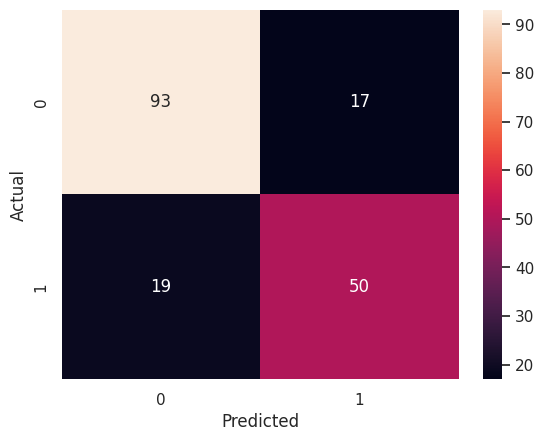

In [ ]:
# 9. Confusion matrix & ROC AUC için RF (örnek)
from sklearn.metrics import roc_auc_score, RocCurveDisplay

probs = pipe_rf.predict_proba(X_test)[:,1]
print("RF ROC AUC:", roc_auc_score(y_test, probs))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted'); plt.ylabel('Actual')

# Model kaydetme
import joblib
joblib.dump(pipe_rf, 'titanic_rf_pipeline.joblib')


İyi uygulamalar ve ileri adımlar (kısa)
Daha fazla özellik mühendisliği (Age için model tabanlı imputasyon, fare transformasyonları).
Cross-validation ve stratified k-fold.
Daha kapsamlı hyperparameter tuning (RandomizedSearchCV, Bayesian).
Feature importance incelemesi ve SHAP ile açıklanabilirlik.
Projeyi GitHub’a koy, README, sonuçlar ve model serileştirmeyi ekle.
Bitirme notu: Bu notebook’u Colab’ta çalıştırıp hücreleri sırayla yürüttüğünde tam bir E2E (end-to-end) ML süreci deneyimi elde edersin.
